# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [1]:
! git clone https://github.com/kayleendo/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 30 (delta 5), reused 4 (delta 4), pack-reused 20 (from 1)
Receiving objects: 100% (30/30), 45.46 KiB | 2.39 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Download complete
Extracting data files...
Data extracted


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. Plain linear models assume that the output is continuous and that a relationship is linear. This limits the models capability. General linear models allow different types of outputs and the mapping of linear combinations into valid ranges. This allows the modeling of nonlinear relationships, respect to contraints, and matching data distributions.

2. Binary and categorical cross entropy comes from maximum likelihood estimation and assumes that data follwos a Bernoilli distribution. This works well for loss functions and fitting regression models because it penalizes confident wrong predictions, is a convex so optimization is easier, and aligns exactly with probability modeling goals.

3. True because the model is linear in its parameters. However, its output is not linear.

4. False because its outputs probabilities that are classified by applying a threshold.

5. No because in linear regression, the coefficient changes in the output. In logistic regression, the coefficient changes in log odds, not probability.

6. False because logistic regression is linear in features, even though the output is nonlinear. This means it cannot learn complex relationships like interactions and polynomial effects.

7. False because it depends on the context and problem. Linear regression is best when predicting continous variables. Logistic regession is better for predicting probabilties or classes.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [ ]:
# 1
df = pd.read_csv("data.csv", sep=';')

cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]

df = df[cols]
df = df.dropna()

df["Dropout_binary"] = df["Target"].apply(
    lambda x: 1 if x == "Dropout" else 0
)

In [ ]:
# 2
X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]
y = df["Dropout_binary"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

coeffs = pd.Series(model.coef_[0], index=X.columns)
print(coeffs)

Debtor                     0.530625
Tuition fees up to date   -2.556542
Scholarship holder        -1.227442
Age at enrollment          0.049925
dtype: float64


Debtor and Age at enrollment both indicate a higher dropout probability, while Tuition and Scholarships indicate a lower dropout probability. Being up to date on tuition suggests a lower dropout rate.

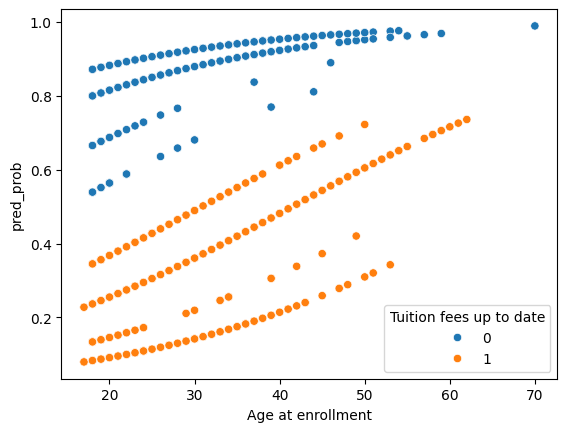

In [ ]:
# 3
df["pred_prob"] = model.predict_proba(X)[:, 1]

sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="pred_prob",
    hue="Tuition fees up to date"
)
plt.show()

Lower ages tend to have lower dropout probabilities for both tuition values (30 years or younger). Values that are not up to date on tuition are almost double the probability of dropping out.

In [ ]:
# 4
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print(acc)

[[2841  162]
 [ 891  530]]
0.7619801084990958


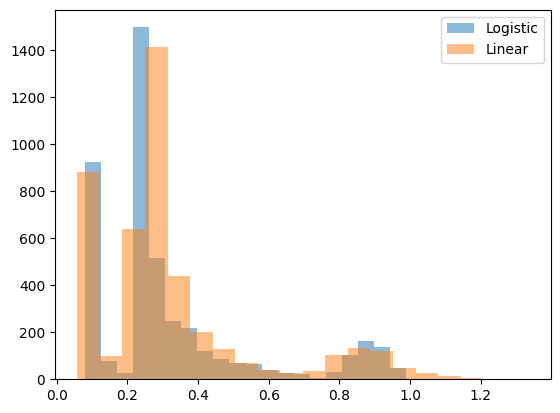

In [ ]:
# 5
lin = LinearRegression()
lin.fit(X, y)

df["lin_prob"] = lin.predict(X)

plt.hist(df["pred_prob"], bins=20, alpha=0.5, label="Logistic")
plt.hist(df["lin_prob"], bins=20, alpha=0.5, label="Linear")
plt.legend()
plt.show()

Logistic regression produces probabilities between 0 and 1, while linear regression produces outputs that are greater than 1. Therefore, logistic regression is more appropriate for this problem.

6

Based on the work above, students with tuition not up to date, have debt, no scholarship, and are older are more at a higher risk of dropping out. Some possible interventions that would help these students are financial aid, additional scholarships, and support programs.

In [ ]:
# 7
X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = df["Target"]

multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(X_multi, y_multi)

y_pred_multi = multi_model.predict(X_multi)
cm_multi = confusion_matrix(y_multi, y_pred_multi)

print(cm_multi)

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The model struggles to distinguish between Graduated and Enrolled students, while predicting the majority class more accurately.

In [ ]:
probs = multi_model.predict_proba(X_multi)
print(probs)

[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 ...
 [0.07193813 0.14064437 0.78741751]
 [0.18422683 0.21266883 0.60310434]
 [0.11780804 0.1769832  0.70520876]]


The predicted probabilities show the likelihood that each student belongs to each class (Dropout, Enrolled, Graduate). Each row sums to 1 and represents a distribution over all possible outcomes.

While the hard classification assigns each student to a single class (the one with the highest probability), the predicted probabilities provide more detailed information about uncertainty.

Even if the hard classification does not predict every class (e.g., rarely predicts “Enrolled”), the predicted probabilities still assign nonzero probabilities to all classes for each student.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [6]:
# 1
df = pd.read_csv("cirrhosis.csv")

df = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]

df["Status"] = df["Status"].map(lambda x: 1 if x in ["C", "CL"] else 0)

# Handle missing values
df = df.dropna()

In [7]:
# 2
df = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)

X = df.drop(columns=["Status", "Stage"])
y = df["Status"]

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

pd.Series(model.coef_[0], index=X.columns)

,0
Bilirubin,-0.351424
Edema_S,-0.450677
Edema_Y,-1.611049
Drug_Placebo,0.231225


Bilirubin and Edema lowers survival probability. Higher bilirubin predicts a lower survival rate than lower bilirubin. Survival rate decreases with Edema_S and greatly decreases with Edema_Y.


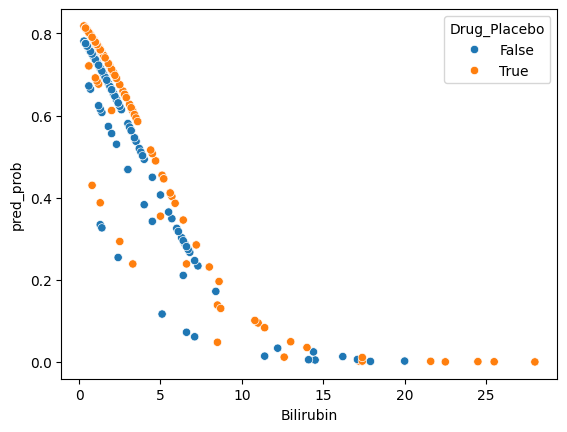

np.float64(-0.018848501038509102)

In [14]:
# 3
df["pred_prob"] = model.predict_proba(X)[:, 1]

sns.scatterplot(
    data=df,
    x="Bilirubin",
    y="pred_prob",
    hue="Drug_Placebo"
)
plt.show()

treated = df[df["Drug_Placebo"] == 0]["pred_prob"].mean()   # drug
control = df[df["Drug_Placebo"] == 1]["pred_prob"].mean()   # placebo

treated - control

 There are no values of Bilirubin that increase patient survival rates. On average, patients who take the drug have a lower predicted survival probability of about 1.9%.

In [15]:
# 4
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

confusion_matrix(y, y_pred)
accuracy_score(y, y_pred)

0.7371794871794872

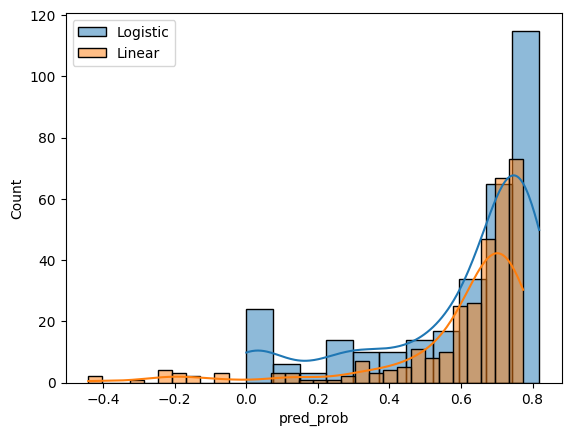

In [16]:
# 5
lin = LinearRegression()
lin.fit(X, y)

df["lin_prob"] = lin.predict(X)

import seaborn as sns

sns.histplot(df["pred_prob"], label="Logistic", kde=True)
sns.histplot(df["lin_prob"], label="Linear", kde=True)
plt.legend()
plt.show()

Logistic regression produces valid probabilities between 0 and 1, while the linear model can produce invalid probabilities outside this range.
Therefore, logistic regression is more appropriate and performs better for predicting survival probabilities.

In [17]:
# 6
X_stage = df[["Bilirubin", "Edema_S", "Edema_Y"]]
y_stage = df["Stage"]

model_stage = LogisticRegression(max_iter=1000, multi_class="multinomial")
model_stage.fit(X_stage, y_stage)

y_pred_stage = model_stage.predict(X_stage)

from sklearn.metrics import confusion_matrix
confusion_matrix(y_stage, y_pred_stage)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


array([[  0,   0,  16,   0],
       [  0,   0,  63,   4],
       [  0,   0, 105,  15],
       [  0,   0,  79,  30]])

The confusion matrix shows that the model struggles to distinguish all four stages.
It tends to predict the more common stages and may fail to predict some classes entirely.

In [19]:
probs = model_stage.predict_proba(X_stage)
print(probs)

[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 ...
 [5.23225350e-02 2.46351600e-01 4.07443845e-01 2.93882020e-01]
 [4.43645995e-02 2.43147794e-01 4.11411355e-01 3.01076251e-01]
 [3.56079503e-03 1.81091914e-01 4.27967363e-01 3.87379928e-01]]


Hard classification struggles to predict some stages, while predicted probabilities include all stages.


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?